In [15]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, statsmodels.api as sm
import data_loader as d

In [31]:
df = d.load_hitting_data()

In [32]:
grouped = df.groupby("season")["OPS"].mean().round(3)
grouped

season
2023    0.922
2024    0.731
2025    0.907
2026    1.263
Name: OPS, dtype: float64

In [18]:
# this is wrong take avg of avg
season_df = df.groupby("season")[["OPS", "SLG", "OBP"]].mean().round(3).reset_index()
season_df 

,season,OPS,SLG,OBP
0,2023,0.922,0.491,0.431
1,2024,0.731,0.381,0.350
2,2025,0.907,0.520,0.388
3,2026,1.263,0.640,0.623


In [19]:
season_df = df.groupby("season")[["H","AB","BB","HBP","SF","TB"]].sum()
season_df["SLG"] = (season_df["TB"] / season_df["AB"]).round(3)
season_df["OBP"] = ((season_df["H"] + season_df["BB"] + season_df["HBP"]) / (season_df["AB"] + season_df["BB"] + season_df["HBP"] + season_df["SF"])).round(3)
season_df["OPS"] = (season_df["OBP"] + season_df["SLG"]).round(3)
season_df.reset_index()

,season,H,AB,BB,HBP,SF,TB,SLG,OBP,OPS
0,2023,39,104,14,1,1,53,0.510,0.450,0.960
1,2024,34,106,6,2,1,41,0.387,0.365,0.752
2,2025,33,98,7,1,0,48,0.490,0.387,0.877
3,2026,17,29,4,1,1,19,0.655,0.629,1.284


In [24]:
season_df[["season", "OPS"]]

,season,OPS
0,2023,0.960
1,2024,0.752
2,2025,0.877
3,2026,1.284


In [27]:
X = sm.add_constant(season_df["season"])
y = season_df["OPS"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    OPS   R-squared:                       0.389
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     1.271
Date:                Mon, 16 Mar 2026   Prob (F-statistic):              0.377
Time:                        17:21:26   Log-Likelihood:                 1.8112
No. Observations:                   4   AIC:                            0.3776
Df Residuals:                       2   BIC:                           -0.8498
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -221.1194    196.998     -1.122      0.3

/Users/destin/Projects/ncaa-softball/venv/lib/python3.9/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


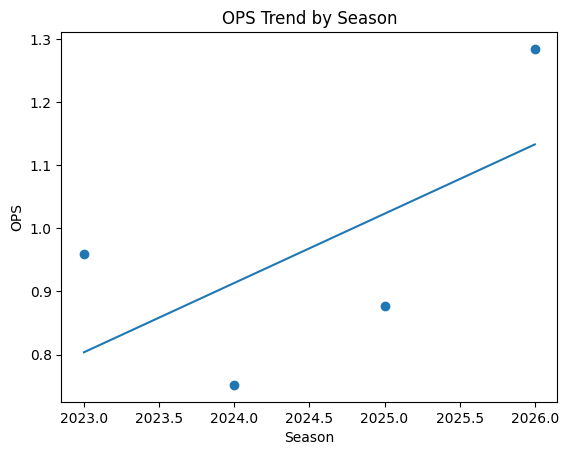

In [29]:
plt.scatter(season_df["season"], y)
plt.plot(season_df["season"], model.fittedvalues)
plt.xlabel("Season")
plt.ylabel("OPS")
plt.title("OPS Trend by Season")
plt.show()